In [50]:
# # 1. Gỡ cài đặt các thư viện cũ
# !pip uninstall numpy pandas prophet cmdstanpy -y

# # 2. Cài đặt đúng phiên bản (theo project gốc)
# !pip install numpy==1.26.4
# !pip install pandas==2.2.2
# !pip install lightgbm==4.3.0 optuna==3.6.1 scikit-learn==1.5.1
# !pip install matplotlib==3.6.0 seaborn==0.13.2 shap==0.44.1
#!pip install streamlit==1.35.0 joblib==1.4.2 pyarrow==20.0.0
!pip install cmdstanpy
!pip install prophet

In [51]:
import numpy as np
import pandas as pd
import prophet
import joblib
import os
import sys
import torch

if torch.cuda.is_available():
    print(f"GPU activated: {torch.cuda.get_device_name(0)}")
else:
    print(" still CPU")

print("NumPy version:", np.__version__)      # Phải là 1.26.4
print("Pandas version:", pd.__version__)     # Phải là 2.2.2
print("Prophet version:", prophet.__version__) # Phải là 1.1.4

GPU activated: NVIDIA A100-SXM4-40GB
NumPy version: 2.0.2
Pandas version: 2.2.2
Prophet version: 1.3.0


In [52]:

# Thêm trực tiếp thư mục gốc của project vào sys.path
project_root = '/content/Walmart_sales_forecasting'
if project_root not in sys.path:
    sys.path.append(project_root)

print("Đã thêm đường dẫn:", project_root)

Đã thêm đường dẫn: /content/Walmart_sales_forecasting


In [94]:
import pandas as pd
import numpy as np
import torch
import prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from src.metrics import weighted_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import joblib


In [54]:
%cd /content/Walmart_sales_forecasting
data_dir = 'data/processed/feature_engineering.feather'
df_feature = pd.read_feather(data_dir)
df_feature

/content/Walmart_sales_forecasting


,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,mean_sales_last_6_week,max_sales_last_6_week,min_sales_last_6_week,std_sales_last_6_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
6,1,1,2010-03-19,22136.64,151315,54.58,2.720,0.00,0.00,0.0,...,30360.018333,63593.12,7612.03,26384.953473,20940.430630,15246.700822,1242589.35,17258.185417,846686.47,18815.254889
149,1,2,2010-03-19,43615.49,151315,54.58,2.720,0.00,0.00,0.0,...,32780.786667,63593.12,7612.03,24477.831239,21538.535315,20414.155206,1242589.35,17258.185417,1742919.72,38731.549333
292,1,3,2010-03-19,9001.37,151315,54.58,2.720,0.00,0.00,0.0,...,29451.181667,61326.35,7612.03,20480.695326,32577.012657,37815.156301,1242589.35,17258.185417,371295.10,8251.002222
435,1,4,2010-03-19,34118.11,151315,54.58,2.720,0.00,0.00,0.0,...,20730.351667,43615.49,7612.03,14443.999382,20789.191329,16204.816575,1242589.35,17258.185417,1064848.12,23663.291556
578,1,5,2010-03-19,22632.57,151315,54.58,2.720,0.00,0.00,0.0,...,25148.031667,43615.49,9001.37,13661.565950,27453.650664,29639.786644,1242589.35,17258.185417,1063601.82,24734.926047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,45,93,2012-10-26,2487.80,118221,58.85,3.882,4018.91,58.08,100.0,...,17814.415000,54608.75,717.82,20287.128190,35354.118359,45312.322469,760281.43,11347.484030,1049693.34,24992.698571
421146,45,94,2012-10-26,5203.31,118221,58.85,3.882,4018.91,58.08,100.0,...,18109.411667,54608.75,1689.10,19999.636394,18920.959180,13193.930617,760281.43,11347.484030,1291378.41,29349.509318
421289,45,95,2012-10-26,56017.47,118221,58.85,3.882,4018.91,58.08,100.0,...,18695.113333,54608.75,2487.80,19466.945450,12062.134590,7200.965154,760281.43,11347.484030,1709432.51,37987.389111
421434,45,97,2012-10-26,6817.48,118221,58.85,3.882,4018.91,58.08,100.0,...,26666.748333,56017.47,2487.80,23647.747335,34039.802295,43813.343789,760281.43,11347.484030,596563.70,13558.265909


In [55]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401996 entries, 6 to 421569
Data columns (total 46 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Store                   401996 non-null  int64         
 1   Dept                    401996 non-null  int64         
 2   Date                    401996 non-null  datetime64[ns]
 3   Weekly_Sales            401996 non-null  float64       
 4   Size                    401996 non-null  int64         
 5   Temperature             401996 non-null  float64       
 6   Fuel_Price              401996 non-null  float64       
 7   MarkDown1               401996 non-null  float64       
 8   MarkDown2               401996 non-null  float64       
 9   MarkDown3               401996 non-null  float64       
 10  MarkDown4               401996 non-null  float64       
 11  MarkDown5               401996 non-null  float64       
 12  CPI                     401996 non-

# **Build Prophet**

In [56]:
test = df_feature[df_feature['is_test']]
train = df_feature[~df_feature['is_test']]

prophet_data = df_feature.groupby(['Date', 'store_dept']).agg(
    {
        'Weekly_Sales' : 'sum',
        'Size' : 'first',
        'Type_B': 'first',         
        'Type_C': 'first',
        'IsHoliday_True' : 'first',
        'Temperature': 'first',
        'Fuel_Price' : 'first',
        "total_markdown": "first",   
        "avg_markdown": "first",      
        "max_markdown": "first",
        'lags_2' : 'first',
        'lags_4' : 'first',
        'lags_6' : 'first',
        'mean_sales_last_2_week' : 'first',
        'mean_sales_last_4_week' : 'first',
        'mean_sales_last_6_week' : 'first',
    }
).reset_index()

# Giả sử IsHoliday_True là 0 hoặc 1, total_markdown là một số
prophet_data['holiday_markdown'] = prophet_data['IsHoliday_True'] * prophet_data['total_markdown']

prophet_data

,Date,store_dept,Weekly_Sales,Size,Type_B,Type_C,IsHoliday_True,Temperature,Fuel_Price,total_markdown,avg_markdown,max_markdown,lags_2,lags_4,lags_6,mean_sales_last_2_week,mean_sales_last_4_week,mean_sales_last_6_week,holiday_markdown
0,2010-03-19,store_10_dept_1,38252.33,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,36572.44,49748.33,40212.84,2922.880,22868.6550,15501.406667,0.0
1,2010-03-19,store_10_dept_10,49479.06,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,49892.15,51199.72,48027.87,38420.625,35960.9575,43116.726667,0.0
2,2010-03-19,store_10_dept_11,30518.98,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,31934.99,33224.65,36705.57,59354.140,45381.1600,43213.585000,0.0
3,2010-03-19,store_10_dept_12,11762.04,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,11033.07,11032.90,10365.86,39999.020,39209.8225,37306.978333,0.0
4,2010-03-19,store_10_dept_13,65575.03,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,70279.43,68060.96,74020.63,21140.510,40247.3250,37300.943333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401991,2012-10-26,store_9_dept_91,914.84,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,698.84,998.95,1043.68,7728.250,6653.1025,6973.853333,0.0
401992,2012-10-26,store_9_dept_92,18310.28,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,20285.74,18333.69,18600.46,2005.805,4241.2575,5020.003333,0.0
401993,2012-10-26,store_9_dept_94,233.02,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,3.88,10.62,116.12,9612.560,8670.4050,7639.588333,0.0
401994,2012-10-26,store_9_dept_95,32382.05,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,32072.80,33119.87,34591.81,9271.650,5638.7275,5918.055000,0.0


In [57]:
#handle missing case
regressor_cols = ['Type_B', 'Type_C', 'IsHoliday_True', 'Temperature', 'Fuel_Price', 'total_markdown']
prophet_data[regressor_cols] = prophet_data[regressor_cols].fillna(0)

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def build_prophet_model(prophet_data,  test_data, checkpoint_dir="/content/drive/MyDrive/Walmart_checkpoints"):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    min_test_time = test_data['Date'].min()
    max_test_time = test_data['Date'].max()
    
    prophet_model = {}
    prophet_predictions = {}
    prophet_metrics = pd.DataFrame(columns=['combo', 'mae', 'rmse', 'wape'])
    all_real = []
    all_predict = [] 
    
    scale_cols = ['Size', 'Temperature', 'Fuel_Price', 'total_markdown', 
                'lags_2', 'lags_4', 'lags_6',
                'mean_sales_last_2_week', 'mean_sales_last_4_week', 'mean_sales_last_6_week',
                'holiday_markdown']
    
    for combination in prophet_data['store_dept'].unique():
        print(f'Build prophet model for {combination}')
        
        model_path = os.path.join(checkpoint_dir,f"{combination}_model.pkl")
        forecast_path = os.path.join(checkpoint_dir,f"{combination}_forecast.csv")
        scaler_path = os.path.join(checkpoint_dir, f"{combination}_scaler.pkl")
        
        if os.path.exists(model_path) and os.path.exists(forecast_path):
            print(f"Load existing {combination}")
            model = joblib.load(model_path)
            forecast = pd.read_csv(forecast_path, parse_dates=['ds'])
            scaler = joblib.load(scaler_path)
            prophet_model[combination] = model
            prophet_predictions[combination] = forecast
            
            # recalc metrics
            mae = mean_absolute_error(forecast['y'], forecast['yhat'])
            rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
            wape = weighted_absolute_percentage_error(forecast['y'], forecast['yhat'])
            prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wape]
            all_real.extend(forecast['y'])
            all_predict.extend(forecast['yhat'])
            continue
        
        combo = prophet_data[prophet_data['store_dept'] == combination]
        combo = combo.rename(columns={'Date':'ds', 'Weekly_Sales' : 'y'}) #prophet require ds and y
        
        combo_train = combo[combo['ds'] < min_test_time]
        combo_test = combo[(combo['ds'] >= min_test_time) & (combo['ds'] <= max_test_time)]
        if combo_train.empty or combo_test.empty:
            print(f'Skip {combination} due to lack of data')
            continue
        
        # standardize value for model to learn
        available_cols = [col for col in scale_cols if col in combo_train.columns] 
        scaler = StandardScaler()
        if available_cols:
            scaler.fit(combo_train[available_cols])
            combo_train = scaler.transform(combo_train[available_cols])
            combo_test = scaler.transform(combo_test[available_cols])
        else:
            scaler = None
        
        # mulitplicative is not suitable for low sales due to being sensitive to changes
        if combo_train['y'].mean() < 50:
            model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True, seasonality_mode='additive', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)
        else:
            model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True, seasonality_mode='multiplicative', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)    
        
        #add regressor to learn
        regressors = ['Type_B', 'Type_C', 'IsHoliday_True'] + available_cols    
        for reg in regressors:
            if reg in combo_train.columns:
                model.add_regressor(reg)
        
        try:
            model.fit(combo_train)
        except Exception as e:
            print(f'Fail to train {combination} : {e}')
            continue
        
        # test
        future = combo_test[['ds'] + regressors]
        forecast = model.predict(future)
        
        forecast = forecast[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].merge(combo_test[['ds', 'y']], on=['ds'])
        
        #save checkpoint
        joblib.dump(model, model_path)
        forecast.to_csv(forecast_path, index=False)
        if scaler is not None:
                    joblib.dump(scaler, scaler_path)
        print(f"Saved checkpoint for {combination}")
        
        prophet_model[combination] = model
        prophet_predictions[combination] = forecast
        
        # evaluate
        mae = mean_absolute_error(forecast['y'], forecast['yhat'])
        rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
        
        wampe = weighted_absolute_percentage_error(forecast['y'], forecast['yhat']).item()
        
        prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wampe]
        
        #overall evaluation
        all_real.extend(forecast['y'])
        all_predict.extend(forecast['yhat'])
        
    
    mean_mae = np.mean(prophet_metrics['mae'])
    mean_rmse = np.mean(prophet_metrics['rmse'])
    ovr_wampe = weighted_absolute_percentage_error(all_real, all_predict)
    
    return prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe)


prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe) = build_prophet_model(prophet_data, test)
    
        
    

Build prophet model for  store_10_dept_1
Load existing  store_10_dept_1
Build prophet model for  store_10_dept_10
Load existing  store_10_dept_10
Build prophet model for  store_10_dept_11
Load existing  store_10_dept_11
Build prophet model for  store_10_dept_12
Load existing  store_10_dept_12
Build prophet model for  store_10_dept_13
Load existing  store_10_dept_13
Build prophet model for  store_10_dept_14
Load existing  store_10_dept_14
Build prophet model for  store_10_dept_16
Load existing  store_10_dept_16
Build prophet model for  store_10_dept_17
Load existing  store_10_dept_17
Build prophet model for  store_10_dept_18
Load existing  store_10_dept_18
Build prophet model for  store_10_dept_19
Load existing  store_10_dept_19
Build prophet model for  store_10_dept_2
Load existing  store_10_dept_2
Build prophet model for  store_10_dept_20
Load existing  store_10_dept_20
Build prophet model for  store_10_dept_21
Load existing  store_10_dept_21
Build prophet model for  store_10_dept_22


INFO:prophet:n_changepoints greater than number of observations. Using 17.


Saved checkpoint for  store_11_dept_51
Build prophet model for  store_11_dept_52
Saved checkpoint for  store_11_dept_52
Build prophet model for  store_11_dept_54
Saved checkpoint for  store_11_dept_54
Build prophet model for  store_11_dept_55
Saved checkpoint for  store_11_dept_55
Build prophet model for  store_11_dept_56
Saved checkpoint for  store_11_dept_56
Build prophet model for  store_11_dept_58
Saved checkpoint for  store_11_dept_58
Build prophet model for  store_11_dept_59
Saved checkpoint for  store_11_dept_59
Build prophet model for  store_11_dept_6
Saved checkpoint for  store_11_dept_6
Build prophet model for  store_11_dept_67
Saved checkpoint for  store_11_dept_67
Build prophet model for  store_11_dept_7
Saved checkpoint for  store_11_dept_7
Build prophet model for  store_11_dept_71
Saved checkpoint for  store_11_dept_71
Build prophet model for  store_11_dept_72
Saved checkpoint for  store_11_dept_72
Build prophet model for  store_11_dept_74
Saved checkpoint for  store_11_d

INFO:prophet:n_changepoints greater than number of observations. Using 6.


Saved checkpoint for  store_30_dept_42
Build prophet model for  store_30_dept_44
Saved checkpoint for  store_30_dept_44
Build prophet model for  store_30_dept_46
Saved checkpoint for  store_30_dept_46
Build prophet model for  store_30_dept_5
Saved checkpoint for  store_30_dept_5
Build prophet model for  store_30_dept_52
Saved checkpoint for  store_30_dept_52
Build prophet model for  store_30_dept_59
Saved checkpoint for  store_30_dept_59
Build prophet model for  store_30_dept_6
Saved checkpoint for  store_30_dept_6
Build prophet model for  store_30_dept_60
Saved checkpoint for  store_30_dept_60
Build prophet model for  store_30_dept_67
Saved checkpoint for  store_30_dept_67
Build prophet model for  store_30_dept_7
Saved checkpoint for  store_30_dept_7
Build prophet model for  store_30_dept_72
Saved checkpoint for  store_30_dept_72
Build prophet model for  store_30_dept_74
Saved checkpoint for  store_30_dept_74
Build prophet model for  store_30_dept_79
Saved checkpoint for  store_30_dep

...

Saved checkpoint for  store_36_dept_72
Build prophet model for  store_44_dept_33


INFO:prophet:n_changepoints greater than number of observations. Using 1.


Saved checkpoint for  store_44_dept_33
Build prophet model for  store_17_dept_47
Skip  store_17_dept_47 due to lack of data
Build prophet model for  store_35_dept_96


INFO:prophet:n_changepoints greater than number of observations. Using 0.
INFO:prophet:n_changepoints greater than number of observations. Using 1.


Saved checkpoint for  store_35_dept_96
Build prophet model for  store_30_dept_99
Saved checkpoint for  store_30_dept_99
Build prophet model for  store_36_dept_32
Saved checkpoint for  store_36_dept_32
Build prophet model for  store_25_dept_48
Skip  store_25_dept_48 due to lack of data
Build prophet model for  store_42_dept_26
Skip  store_42_dept_26 due to lack of data
Build prophet model for  store_44_dept_49
Skip  store_44_dept_49 due to lack of data
Build prophet model for  store_22_dept_96
Skip  store_22_dept_96 due to lack of data
Build prophet model for  store_38_dept_55
Skip  store_38_dept_55 due to lack of data
Build prophet model for  store_19_dept_39
Skip  store_19_dept_39 due to lack of data


In [61]:
print(
    f"Prophet Model Results:\nMAE: {mean_mae:.2f} | RMSE: {mean_rmse:.2f} | WAPE: {ovr_wampe:.2f}"
)

Prophet Model Results:
MAE: 2787.39 | RMSE: 3384.44 | WAPE: 0.21


In [62]:
%cd /content/drive/MyDrive/Walmart_checkpoints
!ls


/content/drive/MyDrive/Walmart_checkpoints
' store_10_dept_10_forecast.csv'  ' store_2_dept_3_model.pkl'
' store_10_dept_10_model.pkl'	  ' store_2_dept_40_forecast.csv'
' store_10_dept_11_forecast.csv'  ' store_2_dept_40_model.pkl'
' store_10_dept_11_model.pkl'	  ' store_2_dept_41_forecast.csv'
' store_10_dept_12_forecast.csv'  ' store_2_dept_41_model.pkl'
' store_10_dept_12_model.pkl'	  ' store_2_dept_42_forecast.csv'
' store_10_dept_13_forecast.csv'  ' store_2_dept_42_model.pkl'
' store_10_dept_13_model.pkl'	  ' store_2_dept_44_forecast.csv'
' store_10_dept_14_forecast.csv'  ' store_2_dept_44_model.pkl'
' store_10_dept_14_model.pkl'	  ' store_2_dept_45_forecast.csv'
' store_10_dept_16_forecast.csv'  ' store_2_dept_45_model.pkl'
' store_10_dept_16_model.pkl'	  ' store_2_dept_46_forecast.csv'
' store_10_dept_17_forecast.csv'  ' store_2_dept_46_model.pkl'
' store_10_dept_17_model.pkl'	  ' store_2_dept_48_forecast.csv'
' store_10_dept_18_forecast.csv'  ' store_2_dept_48_model.pkl'
' stor

In [65]:
# Gộp tất cả dự báo thành một DataFrame
all_forecasts = pd.concat(prophet_predictions.values(), ignore_index=True)
print(all_forecasts.head())

          ds          yhat    yhat_upper    yhat_lower         y
0 2012-08-10  27783.955964  37149.821880  17671.805122  26320.29
1 2012-08-17  26407.651549  37094.268978  16736.943543  26752.40
2 2012-08-24  24898.491170  35399.340224  15592.929228  26804.84
3 2012-08-31  26246.452870  35056.551372  16892.206561  26083.28
4 2012-09-07  27720.431266  37771.736526  18266.937296  29426.33


In [ ]:
import importlib
import src.plots
importlib.reload(src.plots)
from src.plots import visualize_pred, plot_prophet_comparison

df_prophet_pred = visualize_pred(prophet_predictions)
print(df_prophet_pred)

In [89]:
df_prophet_pred.groupby('store_dept').count().reset_index()
df_prophet_pred

,ds,yhat,yhat_upper,yhat_lower,y,store_dept
0,2012-08-10,27783.955964,37149.821880,17671.805122,26320.29,store_10_dept_1
1,2012-08-17,26407.651549,37094.268978,16736.943543,26752.40,store_10_dept_1
2,2012-08-24,24898.491170,35399.340224,15592.929228,26804.84,store_10_dept_1
3,2012-08-31,26246.452870,35056.551372,16892.206561,26083.28,store_10_dept_1
4,2012-09-07,27720.431266,37771.736526,18266.937296,29426.33,store_10_dept_1
...,...,...,...,...,...,...
35504,2012-08-31,-1569.488594,-1569.488571,-1569.488613,5.00,store_36_dept_32
35505,2012-09-14,-2410.389124,-2410.389074,-2410.389168,5.00,store_36_dept_32
35506,2012-09-28,-2071.767594,-2071.767540,-2071.767644,3.75,store_36_dept_32
35507,2012-10-05,-835.107955,-835.107927,-835.107981,3.75,store_36_dept_32


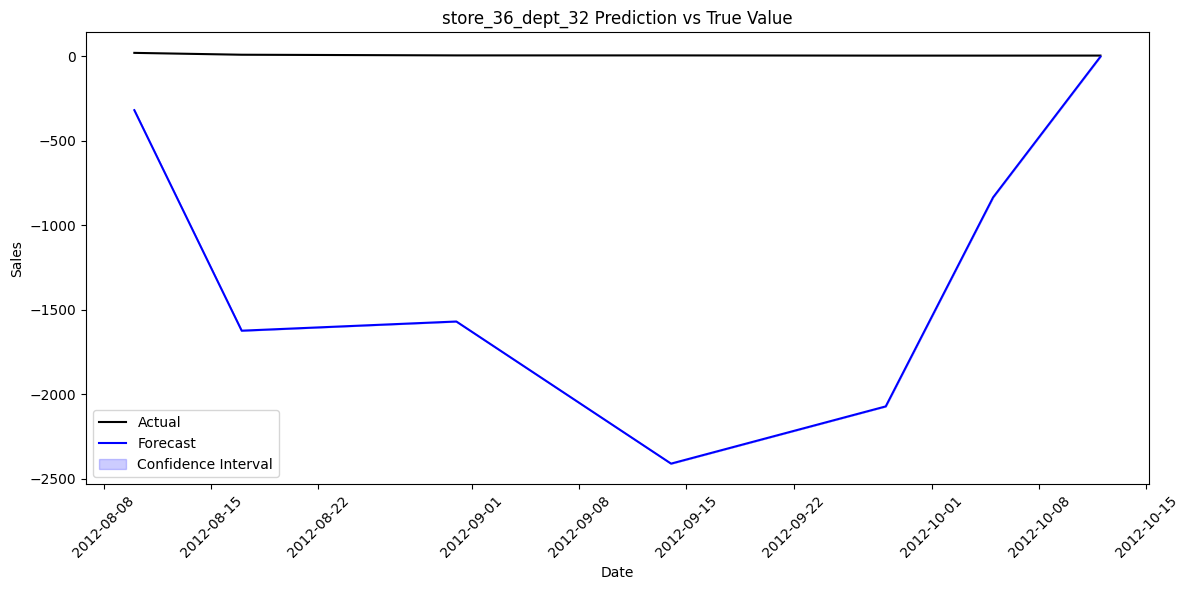

In [93]:
plot_prophet_comparison(df_prophet_pred, store_dept='store_36_dept_32')